# ABテスト入門（３）（吉村）

R で演習するための Google Colab notebook です。Googleアカウントにログインした状態でブラウザから利用できます。

**コードは自由に編集して構いません。**

コメント加筆や修正しながらの利用を奨めます。同時に閲覧する他の利用者とも編集内容は共有されません。
誤ってコード等を消した場合、再び本ページにアクセスし直せばデフォルトから再開できます。
Google driveに本ページ（ipynbファイル）を保存すると編集内容を引き継ぐことができます。

ランタイムは R、ハードウェアは CPU を前提とします。
問い合わせ先：yoshimura at cc.kyoto-su.ac.jp

# コード演習で学ぶこと


*   前回の復習
*   バイアス回避のためのランダム化の理解
*   平均介入効果の可視化
*   平均介入効果の推定量の標本分布
*   ｔ分布の理解
*   ｔ検定のやり方
*   ｔ検定の過誤

# メインコード

In [9]:
# 例：ウェブ広告のABテスト（KPI：ウェブサイト滞在時間）
# A群とB群の潜在結果を用意して、ランダム化してグループ分け
# それぞれの群の平均の差をとって比較

set.seed(1)
n <- 40     # ユーザー数

# 広告Aの方が35秒長く滞在するとする（実際には観測されない）
y_a <- rnorm(n, 65, 5)         # もしも広告Aを見た場合の潜在結果
y_b <- rnorm(n, 30, 5)         # もしも広告Bを見た場合の潜在結果

# ↑ 実際に見たかどうかは関係ない。あくまで潜在的な結果の仮定

Tr <- rbinom(n, 1, 0.5)        # 確率1/2で広告A、でなければ広告B、を決める変数
print(Tr)

 [1] 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 0 1 0 1 0 1
[39] 0 1


In [10]:
# ABテストのデータのイメージ

# 広告Aに割当られたユーザーは広告Aを見たときの滞在時間が記録される
data_a <- y_a[Tr==1]
print(data_a)

# 広告Bに割当られたユーザーは広告Bを見たときの滞在時間が記録される
data_b <- y_b[Tr==0]
print(data_b)

 [1] 65.91822 72.97640 66.64754 67.87891 72.55891 66.94922 61.89380 64.77533
 [9] 64.91905 69.71918 69.10611 67.96951 65.37282 55.05324 68.09913 64.22102
[17] 57.64624 62.60925 67.08971 71.79340 64.73097 62.92503 64.70343 68.81588
 [1] 29.17738 33.48482 26.46252 31.82291 33.84266 34.40554 24.35318 37.16512
 [9] 42.00809 29.80380 30.94396 26.45027 33.05363 23.73183 27.78354 30.37171


In [11]:
# 観測されたデータの平均を計算してみる

cat("広告Ａのグループの平均滞在時間 =", mean(y_a[Tr==1]), "\n")
cat("広告Ｂのグループの平均滞在時間 =", mean(y_b[Tr==0]), "\n")
cat("平均の差 =", mean(y_a[Tr==1]) - mean(y_b[Tr==0]), "\n")

広告Ａのグループの平均滞在時間 = 66.01551 
広告Ｂのグループの平均滞在時間 = 30.92881 
平均の差 = 35.0867 


E[Y1]-E[Y0] = 0.5   (true ATE= 0.5 )


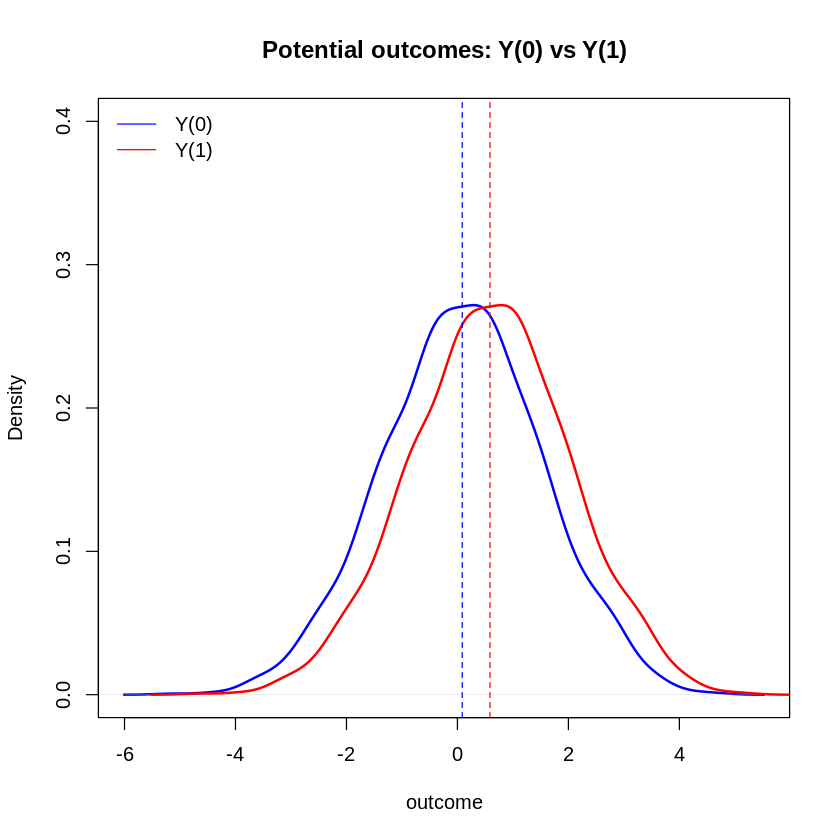

In [12]:
# 潜在結果Y(0),Y(1)の分布と期待値の差の可視化
set.seed(2)

n <- 2000            # 母集団を想定
tau <- 0.5         # 真の介入効果
ability <- rnorm(n)
eps <- rnorm(n)    # 誤差項
y0 <- ability + eps
y1 <- y0 + tau

cat("E[Y1]-E[Y0] =", mean(y1) - mean(y0), "  (true ATE=", tau, ")\n")

# 可視化
plot(density(y0), main="Potential outcomes: Y(0) vs Y(1)", xlab="outcome", lwd=2, col="blue", ylim=c(0, 0.4))
lines(density(y1), lwd=2, col="red")
abline(v=mean(y0), col="blue", lty=2)
abline(v=mean(y1), col="red", lty=2)
legend("topleft", legend=c("Y(0)","Y(1)"), col=c("blue","red"), lty=1, bty="n")

In [13]:
# （発展）ランダム化されていないと、どうなるのか？？
# ランダム化の役割：グループ差は交絡があるとバイアスあるが、ランダム化で改善
set.seed(2)

n <- 2000  # 標本の大きさ
tau <- 0.5 # 真の平均介入効果

# 潜在結果を用意：反実仮想も同時に作ります
ability <- rnorm(n)      # 能力は人によって異なるため乱数で設定
y0 <- ability + rnorm(n) # 介入を受けなかった潜在結果：本来の能力に応じて結果が決まる
y1 <- y0 + tau           # 介入を受けた潜在結果：真の効果だけ増加

Tnr <- as.integer(ability > 0) # 介入するかどうかが自己選択の場合（能力が高い人ほど介入を受けるとする）

cat("自己選択時のグループ間の平均の差 =", mean(y1[Tnr==1]) - mean(y0[Tnr==0]), "\n")

# 真の効果とは大きく異なる推定値になってしまう（バイアスがある、と呼ぶ）

自己選択時のグループ間の平均の差 = 2.151875 


In [14]:
# （発展）ところが、ランダム化により真の介入効果を推定できる
set.seed(2)

Tr <- rbinom(n, 1, 0.5)        # 介入するかどうかが、ダミーが完全にランダムの場合（確率1/2で0/1）

cat(" ランダム化によるグループ間の平均の差 =", mean(y1[Tr==1]) - mean(y0[Tr==0]), "\n")

 ランダム化によるグループ間の平均の差 = 0.4886166 


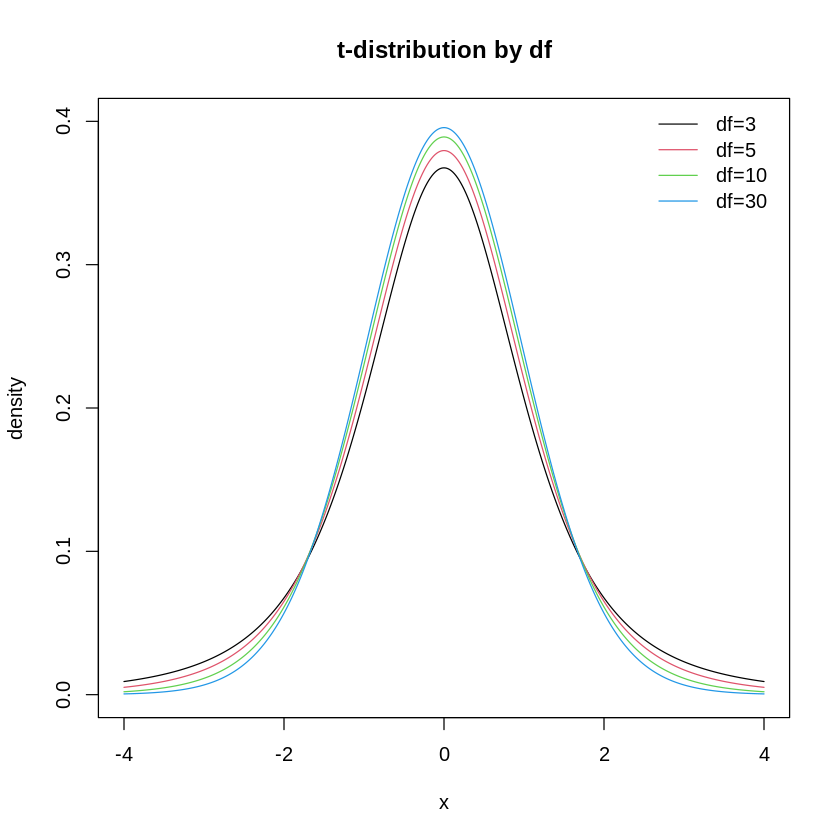

In [15]:
# t分布：自由度別の比較（df = 3,5,10,30 を重ね描き）
x <- seq(-4, 4, length=400)
plot(x, dt(x, df=3), type="l", main="t-distribution by df", ylab="density", ylim=c(0, 0.4)) # t分布の密度関数を描画：dt()
dfs <- c(5, 10, 30) # 自由度 degree of freedom

for (i in 1:length(dfs)) {
  lines(x, dt(x, df=dfs[i]), col=i+1)
  }

legend("topright", legend=paste0("df=", c(3, dfs)), col=1:4, lty=1, bty="n") # 凡例

[1] 0.4951218


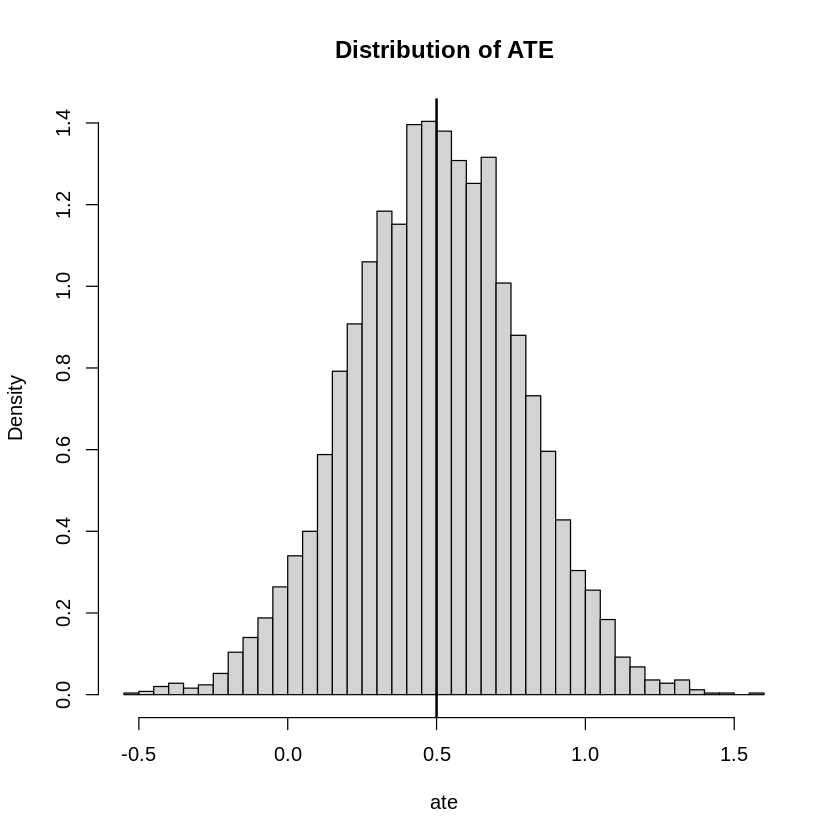

In [16]:
# 平均介入効果(ATE)の推定量の標本分布
# モンテカルロシミュレーション
# あくまで理論の確認のためのシミュレーションです
# 実際のABテストでは「繰り返し標本」は取れないため標本分布は見えない

M <- 5000 # 繰り返し数

n <- 100
tau <- 0.5

# 推定値を格納する変数を用意
ate <- numeric(M)

for (m in 1:M) {
  ability <- rnorm(n)
  y0 <- ability + rnorm(n)
  y1 <- y0 + tau
  Tr <- rbinom(n, 1, 0.5)    # ランダム化
  ate[m] <- mean(y1[Tr==1]) - mean(y0[Tr==0])
  }

hist(ate, prob=TRUE, breaks=40, main="Distribution of ATE"); abline(v=tau, lwd=2)

print(mean(ate))
# 真の効果tauを偏りなく推定できていて、標本分布が正規分布（あるいはｔ分布）に近いことを確認しましょう

[1] 0.4977006


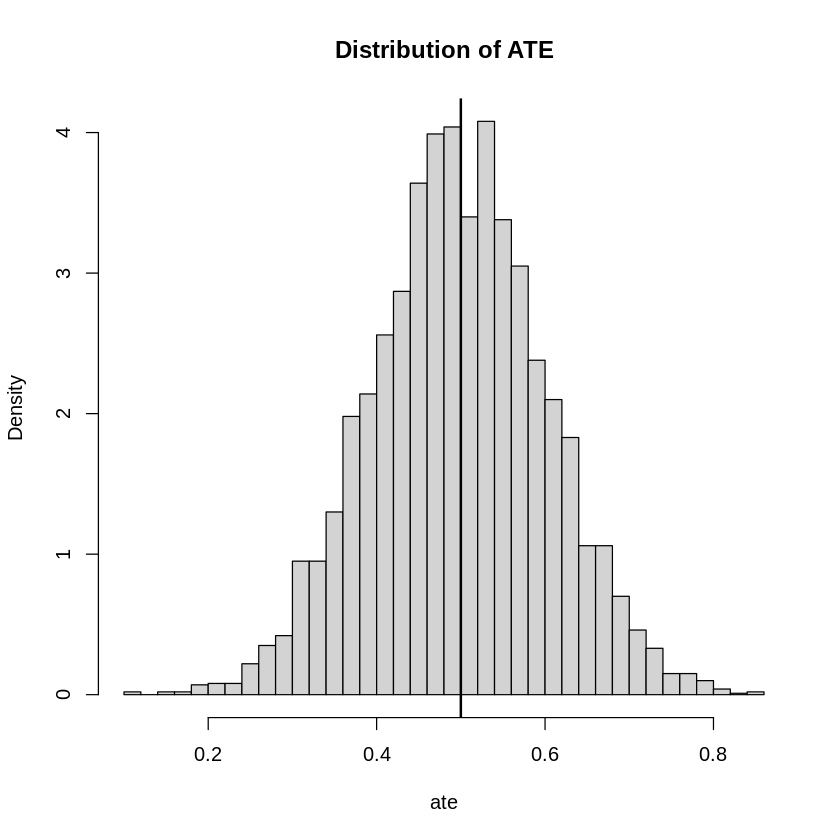

In [18]:
# 上の例で、色々と設定を変えてみて実験してみましょう

M <- 5000 # 繰り返し数

n <- 4000
tau <- 0.5

ate <- numeric(M)

for (m in 1:M) {
  ability <- rnorm(n)
  y0 <- ability + rnorm(n)
  y1 <- y0 + tau
  Tr <- rbinom(n, 1, 0.05)
  ate[m] <- mean(y1[Tr==1]) - mean(y0[Tr==0])
  }

hist(ate, prob=TRUE, breaks=40, main="Distribution of ATE"); abline(v=tau, lwd=2)

print(mean(ate))

In [28]:
# t検定の手続き（等分散を仮定する）
# グループ間（２標本）の平均の差を検定したい
# 一般の２標本の大きさが異なる設定

set.seed(5)
alpha <- 0.05
x <- rnorm(50, mean=0,   sd=2)
y <- rnorm(50, mean=0.5, sd=2)

nx <- length(x)
ny <- length(y)
s2 <- (((nx-1) * var(x) + (ny-1) * var(y)) / (nx + ny - 2))

z <- (mean(x) - mean(y)) / sqrt(s2 * (1/nx + 1/ny)) # z値
crit <- qnorm(1 - alpha/2)
cat("z=", z, "棄却境界= ", crit,"/n")
#cat("t=", t, " df=", df, " p(two-sided)=", 2*(1 - pt(abs(t), df)), "\n") # 時間があれば

z= -0.9657788 棄却境界=  1.959964 /n

In [23]:
# Monte Carlo: t検定の第１種の過誤 ≈ alpha（H0: ATE = 0）
# 帰無仮説「効果は0とする」を棄却できるかどうか
# ｔ検定が犯す誤りは有意水準alphaと同程度になるか確認したい

set.seed(NULL)
M <- 10000 # 繰り返し数

n1 <- 50
n0 <- 50
alpha <- 0.05 # 有意水準は0.05とする（名目上の有意水準）
sigma <- 1

cnt <- 0 # カウント用の変数

df <- n1 + n0 - 2

for (m in 1:M) {
  x <- rnorm(n1, 0, sigma) # 期待値は0とする
  y <- rnorm(n0, 0, sigma) # 期待値は0とする（同一）
  sp2 <- (((n1-1) * var(x) + (n0-1) * var(y)) / df)
  t <- (mean(x) - mean(y)) / sqrt(sp2 * (1/n1 + 1/n0))
  if (2*(1-pt(abs(t),df=df)) < alpha) cnt <- cnt + 1 # 棄却ならカウント、採択ならカウントしない
  }

cat("alpha=",alpha,"  Type-I error ≈",cnt/M,"  (M=",M,")\n")

# 第一種の過誤（仮説が正しいのに棄却する誤り）の確率が、0.05に近いことを確認しよう

alpha= 0.05   Type-I error ≈ 0.0485   (M= 10000 )


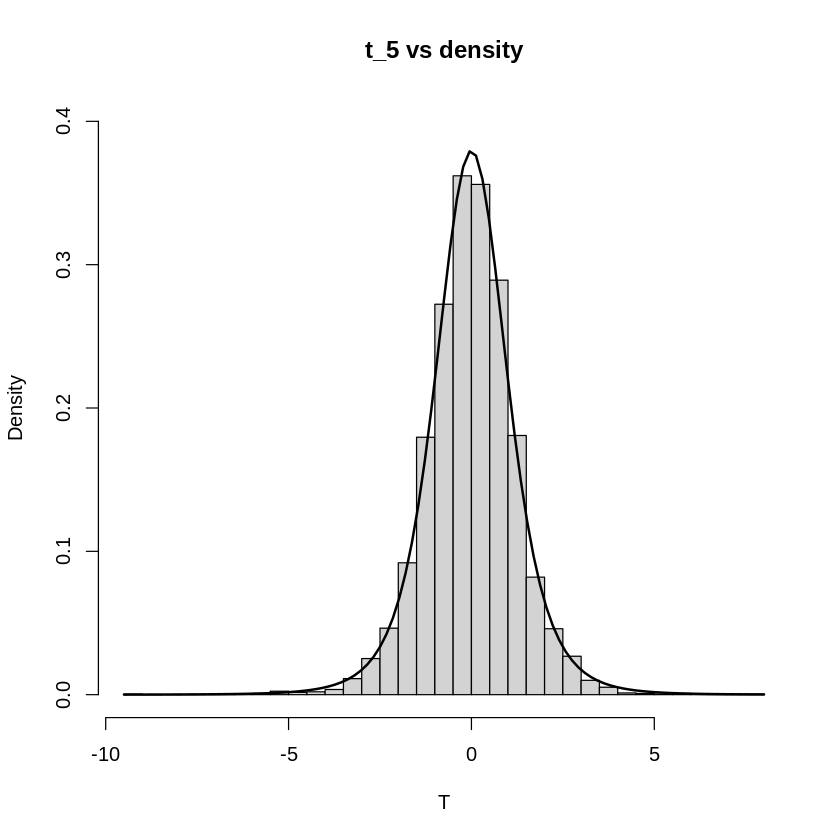

In [21]:
# t分布の構成：T=Z/sqrt(ChiSq/ν) を可視化（※参考資料）
set.seed(4)

nu <- 5 # 自由度を5に設定
Z <- rnorm(5000)

C <- rchisq(5000, df=nu) # χ^2分布からのドロー

T <- Z / sqrt(C / nu) # t分布する変数を構成

hist(T, prob=TRUE, breaks=40, main=paste0("t_", nu, " vs density"), ylim=c(0, 0.4))
curve(dt(x, df=nu), add=TRUE, lwd=2)

# 演習